In [64]:
import gc

# Clear GPU memory
import cupy as cp
cp.get_default_memory_pool().free_all_blocks()
cp.get_default_pinned_memory_pool().free_all_blocks()

# Clear CPU memory
gc.collect()
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI

import os
import sys

# Changing directory for VSCode notebook
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglikebasic
import modeselector
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 0.25     # Total time

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")
# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)

# NOTE: change verbose argument for debugging
loglike_obj = loglikebasic.LogLike(params_star, waveform_gen_comb, gwf, M_init=5, verbose=False, waveform_gen_sep=waveform_gen_sep)
print('Done initializing loglike class.')
print("Setting up log_density and prior functions...")
def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = loglike
        
    return log_likes

def prior_transform(u):
    # 2.5 sigma
    # logm1lim = [5.999851037559485, 6.000148962440515]
    # logm2lim = [1.4770378504576676, 1.4772046589816572]
    # alim = [0.6997315972442014, 0.7002684027557985]
    # p0lim = [7.498519407697586, 7.501480592302414]
    # e0lim = [0.3999359060325742, 0.40006409396742587]

    # 8 sigma
    # logm1lim = [5.999523320190352, 6.000476679809648]
    # logm2lim = [1.476854361081279, 1.4773881483580458]
    # alim = [0.6991411111814447, 0.7008588888185552]
    # p0lim = [7.495262104632274, 7.504737895367726]
    # e0lim = [0.3997948993042373, 0.40020510069576276]

    # 12 sigma
    # logm1lim = [5.9992849802855295, 6.0007150197144705]
    # logm2lim =  [1.4767209142620874, 1.4775215951772374]
    # alim =  [0.6987116667721671, 0.7012883332278328]
    # p0lim = [7.49289315694841, 7.50710684305159]
    # e0lim =  [0.3996923489563559, 0.40030765104364413]

    # 15 sigma
    logm1lim = [5.999106225356911, 6.000893774643089]
    logm2lim = [1.4766208291476937, 1.477621680291631]
    alim = [0.698389583465209, 0.701610416534791]
    p0lim = [7.491116446185513, 7.508883553814487]
    e0lim = [0.39961543619544493, 0.4003845638045551]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Setting up log_density and prior functions...


In [65]:
ffunc_sampler = parismc.Sampler.load_state('./sampling_test/paris_ffunc_files/intrinsic_15s.pkl')

In [66]:
logden_list = ffunc_sampler.searched_log_densities_list[0]
len(logden_list[~np.isfinite(logden_list)])

101196

In [67]:
ffunc_samples, ffunc_weights = ffunc_sampler.get_samples_with_weights(flatten=True)

In [ ]:
log_den = np.array(log_density(ffunc_samples))

In [ ]:
log_den

In [137]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

In [138]:
# 2.5 sigma
param_ranges = [(5.999851037559485, 6.000148962440515),
    (1.4770378504576676, 1.4772046589816572),
    (0.6997315972442014, 0.7002684027557985),
    (7.498519407697586, 7.501480592302414),
    (0.3999359060325742, 0.40006409396742587)]

# # 8 sigma
# param_ranges = [(5.999523320190352, 6.000476679809648),
#     (1.476854361081279, 1.4773881483580458),
#     (0.6991411111814447, 0.7008588888185552),
#     (7.495262104632274, 7.504737895367726),
#     (0.3997948993042373, 0.40020510069576276)]


# 12 sigma
# param_ranges = [(5.9992849802855295, 6.0007150197144705),
#     (1.4767209142620874, 1.4775215951772374),
#     (0.6987116667721671, 0.7012883332278328),
#     (7.49289315694841, 7.50710684305159),
#     (0.3996923489563559, 0.40030765104364413)]

# 15 sigma
# param_ranges = [(5.999106225356911, 6.000893774643089),
#     (1.4766208291476937, 1.477621680291631),
#     (0.698389583465209, 0.701610416534791),
#     (7.491116446185513, 7.508883553814487),
#     (0.39961543619544493, 0.400384563804555)]


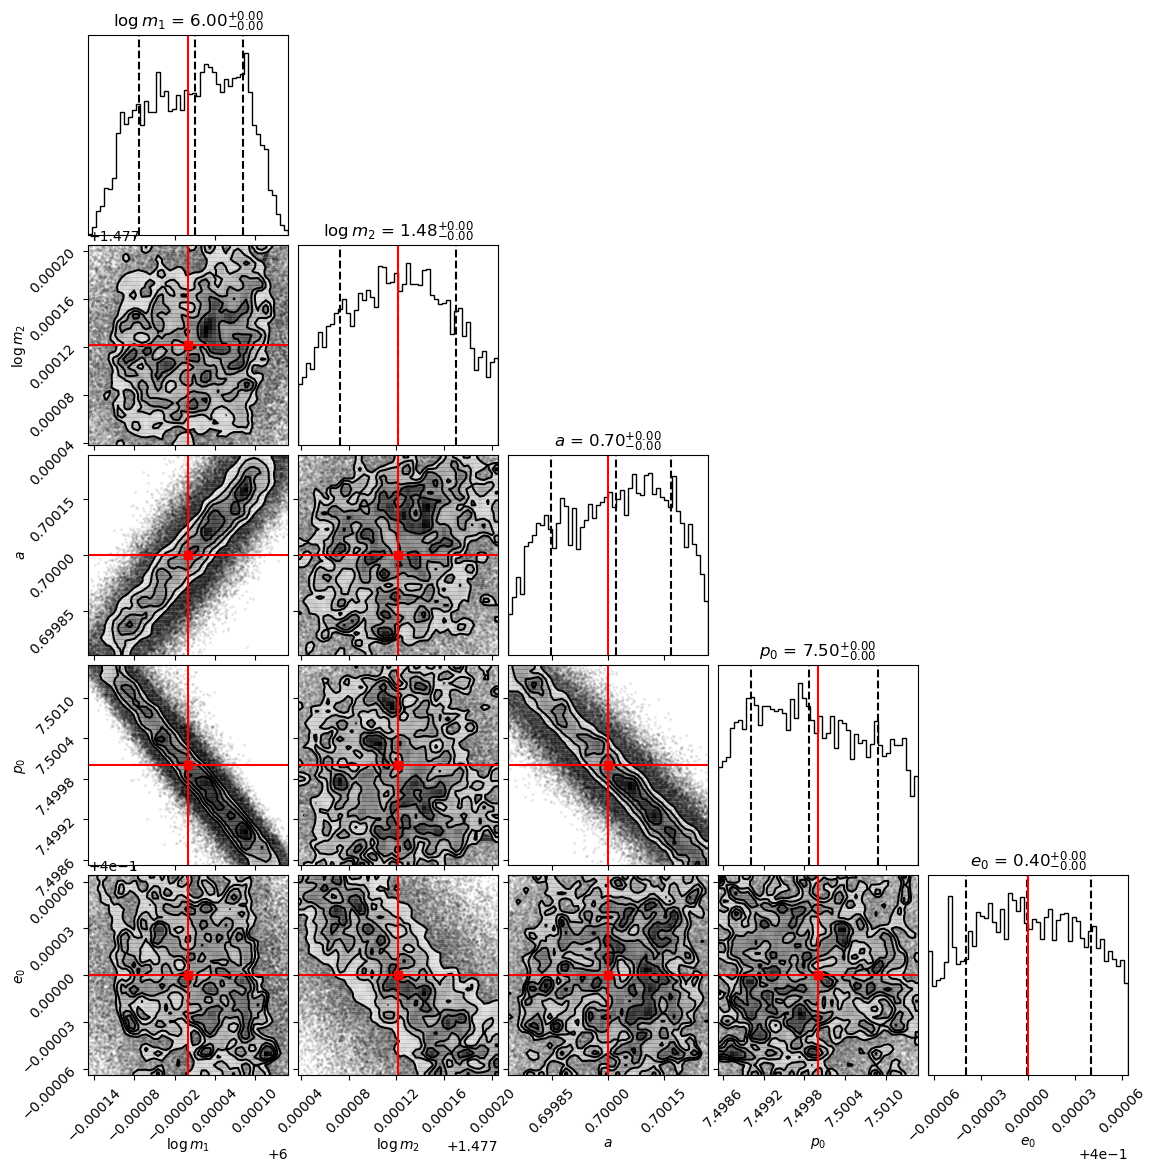

In [139]:
import corner
labels = [r'$\log{m_1}$', r'$\log{m_2}$',r'$a$',r'$p_0$',r'$e_0$']

fig = corner.corner(
    ffunc_samples,
    weights=ffunc_weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],  # 1-sigma and median
    smooth=True,
    bins=50,
    range = param_ranges
)

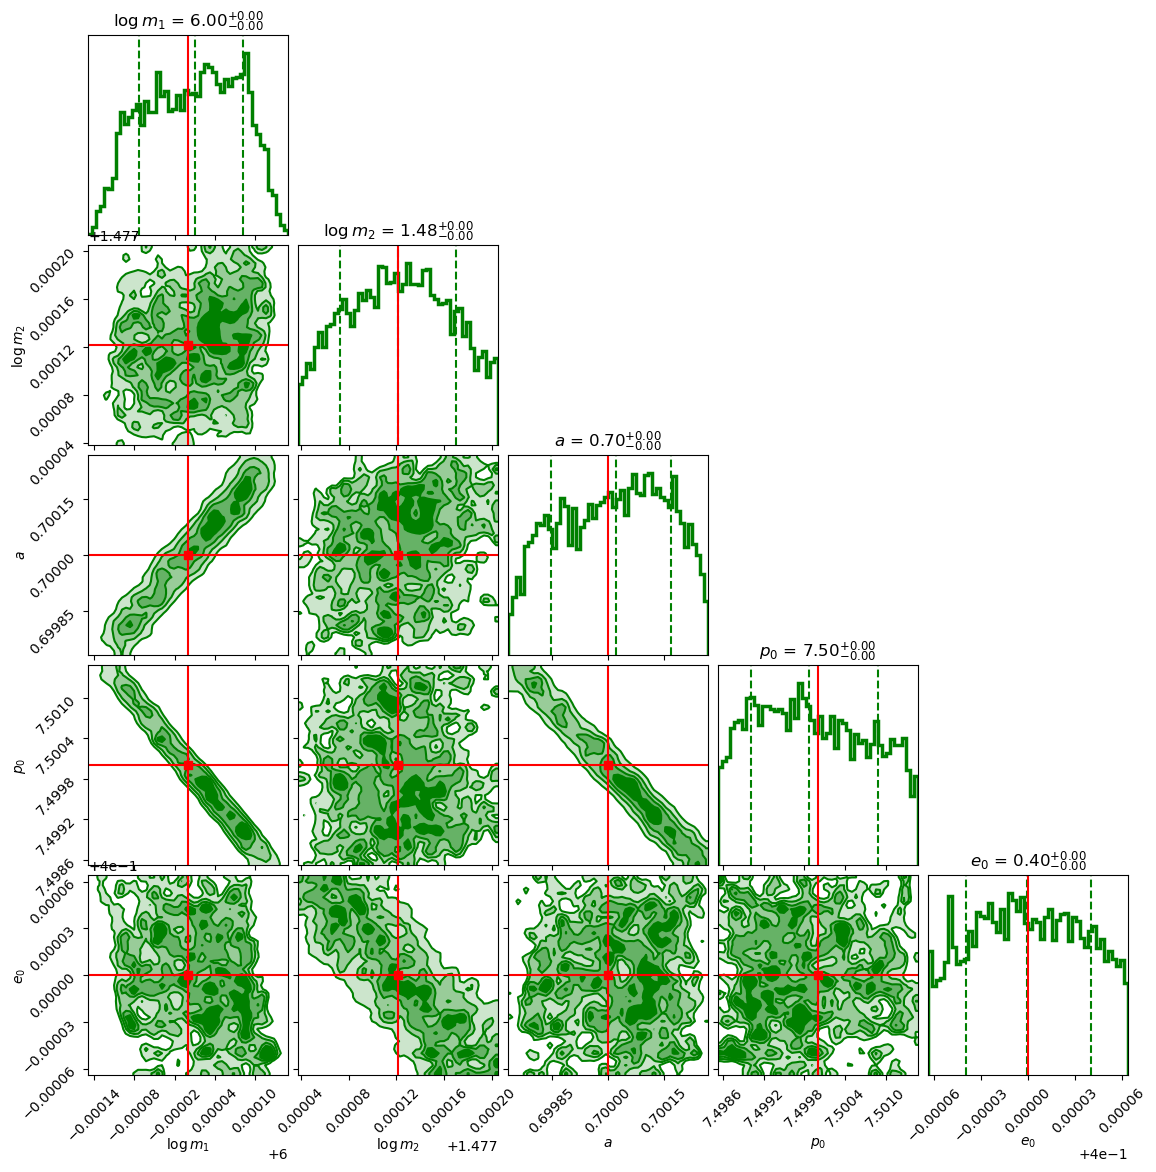

In [140]:
fig = corner.corner(
    ffunc_samples,
    weights=ffunc_weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=50,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

In [141]:
import pickle

with open('./sampling_test/cov_matrix_intrinsic_new.pkl', 'rb') as f:
    cov_mat = pickle.load(f)

# with open('ns_intrinsic2.pkl', 'rb') as f:
#     dres = pickle.load(f)

# dynesty_samples = dres.samples
# dynesty_weights = dres.importance_weights()


In [142]:
from scipy.stats import multivariate_normal

# Generate samples from multivariate normal
n_fisher_samples = 10000
fisher_samples = multivariate_normal.rvs(
    mean=param_true,  # [log_m1, log_m2, a, p0, e0]
    cov=cov_mat,      # Full covariance matrix
    size=n_fisher_samples
)

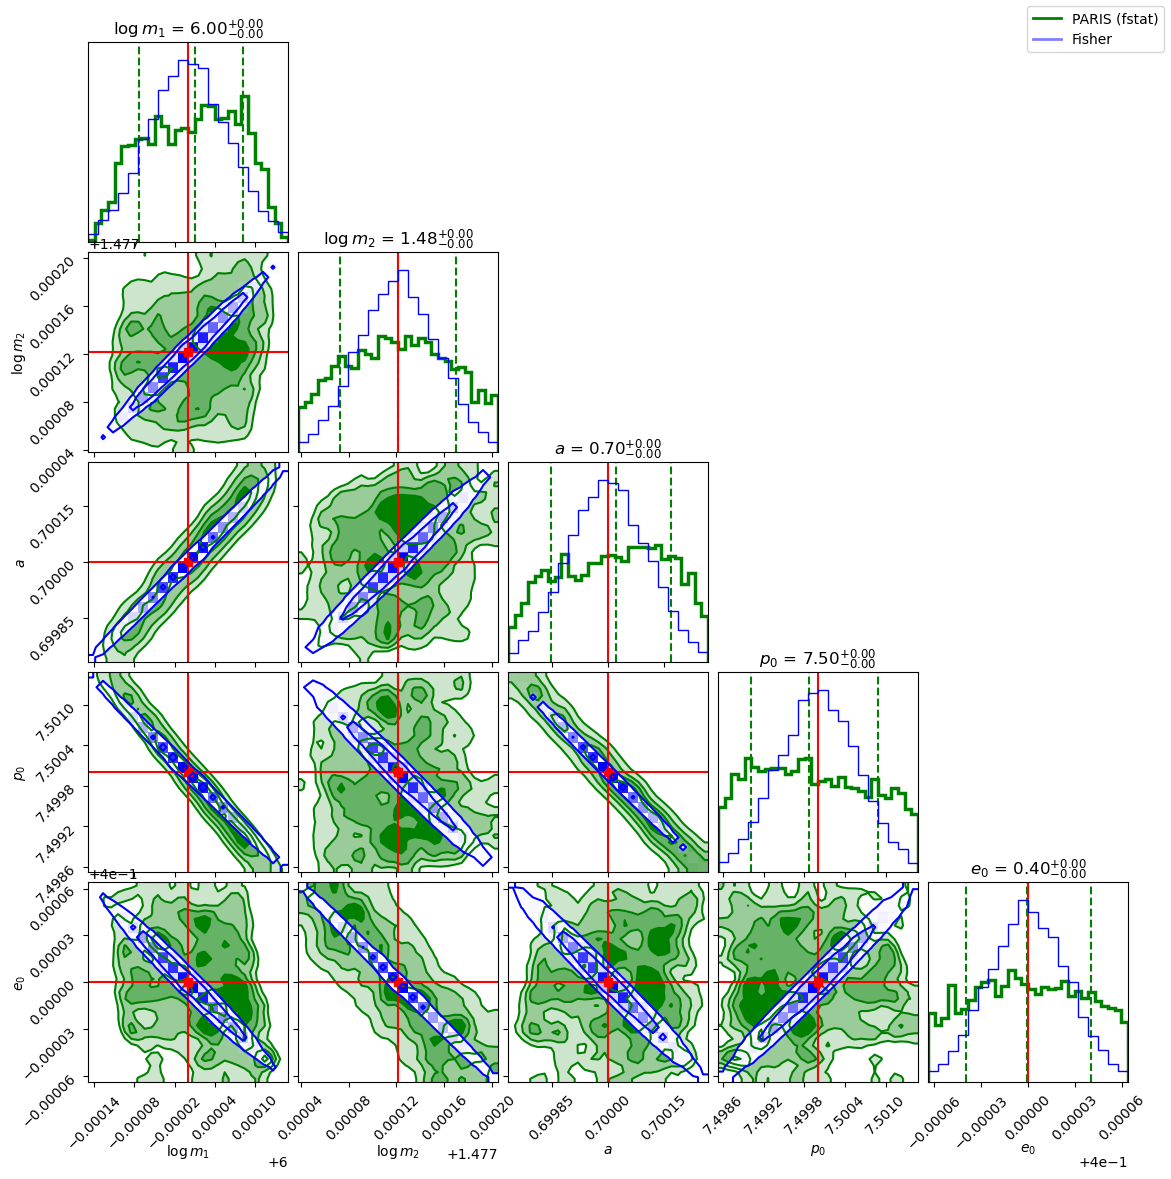

In [145]:
fig = corner.corner(
    ffunc_samples,
    weights=ffunc_weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)


# Overlay Fisher ellipses
corner.corner(
    fisher_samples,
    fig=fig,
    color='blue',
    plot_datapoints=False,
    plot_density=True,
    levels=[0.68, 0.95],
    alpha=0.5,
    hist_kwargs={"density": True},
    range = param_ranges
)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='PARIS (fstat)'),
    Line2D([0], [0], color='blue', lw=2, label='Fisher', alpha=0.5)

]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10)

In [131]:
sigmas = []
for i in range(5):
    sigma_i = np.sqrt(cov_mat[i, i])
    sigmas.append(sigma_i)

In [107]:
param_range = []
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
for i in range(5):
    param_min = param_true[i] - 2.5*sigmas[i]
    param_max = param_true[i] + 2.5*sigmas[i]
    param_range.append([param_min, param_max])

In [108]:
param_range

[[5.999851037559485, 6.000148962440515],
 [1.4770378504576676, 1.4772046589816572],
 [0.6997315972442014, 0.7002684027557985],
 [7.498519407697586, 7.501480592302414],
 [0.3999359060325742, 0.40006409396742587]]